(05-30-wisselkoersen)=

# Wisselkoersen: risk sharing, carry, momentum, value

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1980–2015: van de toetsen van Hansen en Hodrick (1980) en Fama (1984)
via Brandt, Cochrane en Santa-Clara (2006) en de carry-factor van Lustig en
Verdelhan tot de optimale valutaportefeuilles van Barroso en Santa-Clara (2015).

**Wat we al weten.** Elk prijsmodel is een uitspraak over een stochastic discount
factor, $p_t = \E_t[m_{t+1}x_{t+1}]$ ([](#05-26-sdf-unificatie)). De
Hansen-Jagannathan-grens uit [](#03-13-equity-premium-puzzle) zegt dat die SDF
minstens zo volatiel is als de hoogste Sharpe-ratio, ongeveer een half per jaar. In
[](#05-29-opties-crashrisico) zagen we dat strategieën die crashrisico verkopen een
premie verdienen met een scheve verdeling en zeldzame grote verliezen.

**Welke vraag staat open.** Wat vertellen wisselkoersen — de prijs van de ene SDF
uitgedrukt in de andere — over hoe marginaal nut in verschillende landen samen
beweegt, en is het rendement van lenen in lage-rentevaluta's en beleggen in
hoge-rentevaluta's een beloning voor risico of een vergissing van de markt?
```

## Overzicht

Een wisselkoers is de ruilverhouding tussen twee rekeneenheden, en elke rekeneenheid heeft
haar eigen stochastic discount factor. In volledige markten volgt daaruit een identiteit die
de hele lecture draagt: de procentuele verandering van de wisselkoers is het verschil tussen
de logaritmen van de buitenlandse en de binnenlandse SDF
{cite}`BackusForesiTelmer2001,Bekaert1996`. Wisselkoersen zijn daarmee een venster op het
verschil tussen twee grootheden die we afzonderlijk nooit waarnemen.

Brandt, Cochrane en Santa-Clara zagen in 2006 wat dat venster laat zien
{cite}`BrandtCochraneSantaClara2006`. Aandelenpremies zeggen dat marginaal nut in elk land
met minstens vijftig procent per jaar schommelt; wisselkoersen schommelen met ongeveer tien
procent. Dan moeten de SDF's van landen bijna perfect samen bewegen: internationale risk
sharing is veel beter dan consumptiedata doen vermoeden — of wisselkoersen zijn te glad. Dat
werk definieert het tijdvak omdat het een oude macro-vraag (delen landen hun risico?) omzet in
een asset-pricingvraag die je met één regel algebra en twee standaarddeviaties beantwoordt.

Het tweede verhaal is dat van de *uncovered interest parity* (UIP, ongedekte renteparititeit:
de verwachte depreciatie van een valuta is gelijk aan het renteverschil). Sinds Hansen en
Hodrick {cite}`HansenHodrick1980` en Fama {cite}`Fama1984` weten we dat die voorspelling
faalt, meestal met het verkeerde teken. Dat maakt de *carry trade* (lenen in een valuta met
lage rente, uitzetten in een valuta met hoge rente) winstgevend. Epistemisch is dit motief 3
in zuivere vorm: een verworpen theorie die een feit werd, met daarna concurrerende
verklaringen — consumptierisico {cite}`LustigVerdelhan2007`, een gemeenschappelijke
carry-factor {cite}`LustigRoussanovVerdelhan2011`, volatiliteitsrisico
{cite}`MenkhoffSarnoSchmelingSchrimpf2012a`, crashrisico {cite}`BrunnermeierNagelPedersen2008`
en peso problems {cite}`BurnsideEichenbaumKleshchelskiRebelo2011`. Barroso en Santa-Clara
voegden momentum en value toe en vroegen welke combinatie een belegger zou moeten aanhouden
{cite}`BarrosoSantaClara2015b`.

Na een toy-voorbeeld met twee landen leiden we de risk-sharing-index, de Fama-decompositie en
de carry-premie af, simuleren we de onzekerheid van de index en een carry trade met zeldzame
crashes, en repliceren we op FRED-data voor negen G10-valuta's de Fama-regressie, de
carry-portefeuilles met hun crash van 2008, de index van Brandt, Cochrane en Santa-Clara, en
kort momentum en value.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Neem een Amerikaanse en een Zwitserse belegger. Een SDF is een lijst van waarderingen: hoeveel
een extra eenheid van de eigen munt in elke toekomstige toestand waard is. Als een dollar in
een bepaalde toestand voor de Amerikaan heel waardevol is — omdat het de Amerikaanse economie
slecht gaat — en een frank voor de Zwitser dan niet bijzonder, moet de dollar in die toestand
duur worden ten opzichte van de frank. De wisselkoers beweegt met het verschil tussen hoe
hongerig de twee beleggers naar hun eigen munt zijn.

Tel nu. Om een Sharpe-ratio van een half te prijzen, moet marginaal nut met minstens de helft
per jaar op en neer gaan. Dollar-frank beweegt met ongeveer tien procent per jaar. Twee
grootheden die elk met vijftig procent schommelen en waarvan het verschil maar met tien procent
schommelt, moeten vrijwel altijd samen bewegen. Wie risico's slecht deelt, zou wisselkoersen zien
die zeven keer zo volatiel zijn. Consumptiedata zeggen het tegendeel: consumptiegroei is tussen
landen matig gecorreleerd. Dan is consumptie een slechte maatstaf van marginaal nut, of zijn
wisselkoersen te glad.

Dan de rente. Het leerboek zegt: als de Australische rente vier procent hoger is dan de Japanse,
depreciëert de Australische dollar naar verwachting vier procent per jaar, zodat beide
beleggingen in dezelfde munt hetzelfde opleveren. In de data depreciëert hij gemiddeld veel
minder, of appreciëert hij zelfs. Wie in yen leent en in Australische dollars belegt, verdient
het renteverschil en houdt het meestal.

Is dat gratis geld? Hoge-rentevaluta's zijn valuta's van landen met weinig voorzorgssparen; yen
en frank zijn toevluchtsoorden. In een wereldwijde paniek, als iedereen tegelijk posities
afbouwt, stijgen yen en frank en vallen de Australische en Nieuw-Zeelandse dollar, zoals in
oktober 2008. Valuta's "go up by the stairs and down by the elevator". Een strategie die in de
slechtste tijden hard verliest, draagt risico waar een SDF een hoge prijs op zet. Maar een
strategie die in dertig jaar geen crash meemaakt, kan er ook als vrije lunch uitzien terwijl het
risico nog niet is gematerialiseerd: het *peso problem* (risico dat in de prijzen zit maar niet in
de steekproef). Santa-Clara's praktijkles is precies die vraag: draag je geprijsd risico, of denk
je iets te weten wat de prijs niet weet {cite}`SantaClara2026`?

## Toy-voorbeeld: twee landen, twee toestanden

Er zijn twee toestanden op $t+1$, elk met kans $\tfrac12$. De Amerikaanse SDF $m$ prijst
dollarpayoffs, de buitenlandse $m^*$ payoffs in frank:

| toestand | kans | $m$ (dollar) | $m^*$ (frank) |
|---|---|---|---|
| goed   | 0{,}5 | 0{,}80 | 0{,}88 |
| slecht | 0{,}5 | 1{,}20 | 1{,}08 |

**Rentes.** $R^f = 1/\E[m] = 1/1{,}00 = 1{,}00$ en $R^{f*} = 1/\E[m^*] = 1/0{,}98 = 1{,}0204$. Het
land met de minder volatiele SDF heeft de hogere rente: er is minder reden voor voorzorgssparen.

**Wisselkoers.** Laat $S_t$ de dollarprijs van één frank zijn. Volgens de identiteit hieronder is
$S_{t+1}/S_t = m^*/m$: $0{,}88/0{,}80 = 1{,}10$ in de goede en $1{,}08/1{,}20 = 0{,}90$ in de
slechte toestand. De frank appreciëert tien procent als het goed gaat en depreciëert tien procent
als het slecht gaat.

**Controle.** Per dollar belegd levert de frankobligatie $R^{f*} S_{t+1}/S_t$ op:
$1{,}0204 \cdot 1{,}10 = 1{,}1224$ of $1{,}0204 \cdot 0{,}90 = 0{,}9184$. De Amerikaanse SDF
waardeert dat op $\tfrac12(0{,}80 \cdot 1{,}1224 + 1{,}20 \cdot 0{,}9184) = \tfrac12(0{,}8980 +
1{,}1020) = 1{,}0000$, precies één dollar.

**UIP en carry.** De verwachte wisselkoersverandering is $\tfrac12(1{,}10 + 0{,}90) = 1{,}00$,
terwijl UIP $R^f/R^{f*} = 0{,}98$ voorspelt. Wie een dollar leent en in de frankobligatie belegt,
verdient $+12{,}24\%$ in de goede en $-8{,}16\%$ in de slechte toestand, gemiddeld $+2{,}04\%$.
Geen arbitrage: de strategie verliest precies wanneer $m$ hoog is. Met afwijkingen $\mp 0{,}20$
voor $m$ en $\pm 0{,}1020$ voor het excess rendement is $\Cov = -0{,}0204$, dus de risicopremie
$-\Cov/\E[m] = 0{,}0204$: het hele renteverschil.

**Risk sharing.** $\log m = (-0{,}2231;\ 0{,}1823)$ heeft standaarddeviatie $0{,}2027$,
$\log m^* = (-0{,}1278;\ 0{,}0770)$ heeft $0{,}1024$, en $\Delta s = (0{,}0953;\ -0{,}1054)$ heeft
$0{,}1003$. De risk-sharing-index $1 - \Var(\Delta s)/(\Var(\log m) + \Var(\log m^*))$ is
$1 - 0{,}01007/(0{,}04110 + 0{,}01049) = 0{,}805$: de log-SDF's zijn met twee toestanden perfect
gecorreleerd, maar de index bestraft ook verschil in grootte.

**Lognormale benadering.** De log-carry-premie is $\log 1{,}0204 + \E[\Delta s] = 0{,}0202 -
0{,}0050 = 0{,}0152$; de formule $\tfrac12(\Var(\log m) - \Var(\log m^*))$ uit de theorie geeft
$0{,}0153$.

In [2]:
prob = np.array([0.5, 0.5])
m_home = np.array([0.80, 1.20])        # US SDF, prices dollar payoffs
m_foreign = np.array([0.88, 1.08])     # foreign SDF, prices franc payoffs


def pvar(x):
    """Population variance under the state probabilities."""
    return prob @ (x - prob @ x) ** 2


Rf, Rf_star = 1 / (prob @ m_home), 1 / (prob @ m_foreign)
fx_growth = m_foreign / m_home                         # S_{t+1} / S_t
carry_payoff = Rf_star * fx_growth                      # dollars per dollar in the franc bill
log_m, log_m_star, ds_toy = np.log(m_home), np.log(m_foreign), np.log(fx_growth)
toy = {
    "R^f": Rf, "R^f*": Rf_star,
    "S'/S goed": fx_growth[0], "S'/S slecht": fx_growth[1],
    "prijs frankobligatie E[m R* S'/S]": prob @ (m_home * carry_payoff),
    "E[S'/S]": prob @ fx_growth, "UIP: R^f / R^f*": Rf / Rf_star,
    "carry excess goed": carry_payoff[0] - Rf, "carry excess slecht": carry_payoff[1] - Rf,
    "E[carry excess]": prob @ carry_payoff - Rf,
    "sd log m": np.sqrt(pvar(log_m)), "sd log m*": np.sqrt(pvar(log_m_star)), "sd ds": np.sqrt(pvar(ds_toy)),
    "risk-sharing-index": 1 - pvar(ds_toy) / (pvar(log_m) + pvar(log_m_star)),
    "log-carry-premie (exact)": np.log(Rf_star / Rf) + prob @ ds_toy,
    "log-carry-premie (lognormaal)": 0.5 * (pvar(log_m) - pvar(log_m_star)),
}
hand = [1.0, 1.0204, 1.10, 0.90, 1.0, 1.0, 0.9804, 0.1224, -0.0816, 0.0204,
        0.2027, 0.1024, 0.1003, 0.805, 0.0152, 0.0153]
print("code == handberekening:", np.allclose(list(toy.values()), hand, atol=6e-4))
pd.Series(toy).round(4)

code == handberekening: True


R^f                                  1.0000
R^f*                                 1.0204
S'/S goed                            1.1000
S'/S slecht                          0.9000
prijs frankobligatie E[m R* S'/S]    1.0000
E[S'/S]                              1.0000
UIP: R^f / R^f*                      0.9800
carry excess goed                    0.1224
carry excess slecht                 -0.0816
E[carry excess]                      0.0204
sd log m                             0.2027
sd log m*                            0.1024
sd ds                                0.1003
risk-sharing-index                   0.8048
log-carry-premie (exact)             0.0152
log-carry-premie (lognormaal)        0.0153
dtype: float64

## Theorie

### Opzet en notatie

Het binnenland is de VS. $S_t$ is de dollarprijs van één eenheid buitenlandse munt en
$s_t = \log S_t$; een positieve $\Delta s_{t+1}$ betekent dat de buitenlandse munt appreciëert.
$m_{t+1}$ prijst dollarpayoffs, $m^*_{t+1}$ payoffs in buitenlandse munt. De log risicovrije
rentes $i_t$ en $i^*_t$ voldoen aan $e^{i_t} = 1/\E_t[m_{t+1}]$ en $e^{i^*_t} = 1/\E_t[m^*_{t+1}]$.
Het log excess rendement van lenen in dollars en één periode beleggen in de buitenlandse obligatie
is

```{math}
:label: eq-wisselkoersen-rx
rx_{t+1} = i^*_t - i_t + \Delta s_{t+1} .
```

Sterren betekenen hier "buitenland", niet "optimaal".

### De wisselkoers als verhouding van twee SDF's

*Waarom zou dit waar zijn?* Een Amerikaan kan een buitenlandse payoff kopen door dollars om te
wisselen en de opbrengst terug te wisselen. Voor hem is het een dollarpayoff maal de
wisselkoersverandering, en zijn eigen SDF moet die juist prijzen. Dus is "$m$ maal de
wisselkoersverandering" een geldige buitenlandse SDF; is er maar één, dan moet het deze zijn.

:::{prf:proposition} Wisselkoers en SDF's
:label: thm-wisselkoersen-identiteit

Laat $m_{t+1}$ alle verhandelde dollarpayoffs prijzen, en laat buitenlandse payoffs vrij in
dollars omgewisseld kunnen worden.

1. Dan prijst $m_{t+1} S_{t+1}/S_t$ alle verhandelde payoffs in buitenlandse munt.
2. Zijn de markten volledig, zodat beide SDF's uniek zijn, dan geldt
   ```{math}
   :label: eq-wisselkoersen-identiteit
   \frac{S_{t+1}}{S_t} = \frac{m^*_{t+1}}{m_{t+1}},
   \qquad
   \Delta s_{t+1} = \log m^*_{t+1} - \log m_{t+1} .
   ```
3. Zijn de markten onvolledig, dan bestaat er voor elke dollar-SDF $m$ een buitenlandse SDF
   waarvoor [](#eq-wisselkoersen-identiteit) geldt.
:::

:::{prf:proof}
Een buitenlandse payoff $x^*_{t+1}$ met prijs $p^*_t$ kost $p^*_t S_t$ dollar en levert
$x^*_{t+1} S_{t+1}$ dollar op. Omdat $m$ alle dollarpayoffs prijst, is
$p^*_t S_t = \E_t[m_{t+1} x^*_{t+1} S_{t+1}]$; delen door $S_t$ geeft
$p^*_t = \E_t[(m_{t+1}S_{t+1}/S_t)\, x^*_{t+1}]$, deel 1. Bij volledige markten is de
buitenlandse SDF uniek, dus $m^*_{t+1} = m_{t+1}S_{t+1}/S_t$; logaritmen geven deel 2. Deel 3 is
deel 1 met $m^* \equiv m S_{t+1}/S_t$. $\square$
:::

Brandt, Cochrane en Santa-Clara schrijven dit als hun vergelijking (1),
$\ln(e_{t+1}/e_t) = \ln m^f_{t+1} - \ln m^d_{t+1}$; wij schrijven $S$, $m$ en $m^*$ voor $e$,
$m^d$ en $m^f$. Een wisselkoers heeft dus geen "fundamentele waarde" los van de SDF's; hij *is* de
relatieve SDF. Ook rentes zijn geen vrije parameters: $i_t - i^*_t = \log\E_t[m^*] - \log\E_t[m]$.

### Hoe glad mogen wisselkoersen zijn?

*Waarom zou dit waar zijn?* De variantie van een verschil is de som van de varianties min twee
keer de covariantie. Links in [](#eq-wisselkoersen-identiteit) staat iets kleins, rechts het
verschil van twee zeer volatiele grootheden; een grote covariantie moet het verschil wegwerken.

:::{prf:proposition} Risk-sharing-index
:label: thm-wisselkoersen-bcs

Onder [](#eq-wisselkoersen-identiteit) geldt

```{math}
:label: eq-wisselkoersen-bcs
\Var(\Delta s) = \Var(\log m) + \Var(\log m^*) - 2\Cov(\log m, \log m^*),
\qquad
1 - \frac{\Var(\Delta s)}{\Var(\log m) + \Var(\log m^*)}
= \frac{2\Cov(\log m, \log m^*)}{\Var(\log m) + \Var(\log m^*)} .
```

De linkerkant van de tweede vergelijking is de risk-sharing-index van
{cite:t}`BrandtCochraneSantaClara2006` (hun vergelijking (2)): één bij $\log m = \log m^*$, nul
bij ongecorreleerde SDF's. Is bovendien $\SD(\log m) \geq a$ en $\SD(\log m^*) \geq a$, dan is

```{math}
:label: eq-wisselkoersen-rhomin
\Corr(\log m, \log m^*) \;\geq\; 1 - \frac{\Var(\Delta s)}{2a^2}.
```
:::

:::{prf:proof}
De eerste vergelijking is de variantie van $\log m^* - \log m$; de tweede volgt door te delen
door $\Var(\log m) + \Var(\log m^*)$. De grens [](#eq-wisselkoersen-rhomin) is oefening
[](#ex-wisselkoersen-1). $\square$
:::

De grens $a$ komt uit de Hansen-Jagannathan-grens [](#eq-equity-premium-puzzle-hj),
$\SD(m)/\E[m] \geq |\mathrm{SR}|$. Die gaat over het niveau van $m$. Is $m$ lognormaal met
log-standaarddeviatie $\sigma$, dan is $\SD(m)/\E[m] = \sqrt{e^{\sigma^2} - 1}$, dus

```{math}
:label: eq-wisselkoersen-logbound
\SD(\log m) \;\geq\; a = \sqrt{\log\left(1 + \mathrm{SR}^2\right)} ,
```

bij $\mathrm{SR} = 0{,}5$ is $a = 0{,}47$. Brandt, Cochrane en Santa-Clara geven het
rekenvoorbeeld zelf (werkpapierversie van 2002): "A 10% exchange rate volatility and a 50%
marginal utility growth volatility in each country imply a risk sharing index of
1-0.1²/(2×0.5²) = 0.98"; zonder risk sharing zouden wisselkoersen "by √2 × 0.5 = 71% or more"
moeten schommelen. Voor de VS tegenover het Verenigd Koninkrijk, Duitsland en Japan, met
maandelijkse reële excess rendementen, vonden ze wisselkoersvolatiliteiten van 11,51% tot 12,89%
(tabel 1), SDF-volatiliteiten "of the order of 0.63 to 0.69" en indices "all at or above 0.98"
met een standaardfout van ongeveer 0,01 (tabel 2) — hoewel de SDF-volatiliteiten zelf
standaardfouten van 0,13 tot 0,21 hebben. Pas bij een ware aandelenpremie van 4% zakt de index
naar 0,91 (tabel 3). De gepubliceerde versie hebben we niet kunnen inzien.

Tegenover die 0,98 staan consumptiedata: consumptiegroei is tussen landen matig gecorreleerd, en
reële wisselkoersen bewegen nauwelijks met relatieve consumptie {cite}`BackusSmith1993`. Welke kant
het mis heeft, zegt de index niet.

### Covered en uncovered interest parity

*Waarom zou dit waar zijn?* Wie dollars in franken wisselt, frankrente ontvangt en de franken op
termijn terugverkoopt, heeft een risicovrije dollarbelegging gebouwd. Die moet de dollarrente
opleveren, en de verwachte toekomstige wisselkoers komt er niet aan te pas.

Laat $F_t$ de termijnkoers zijn en $f_t = \log F_t$. Eén dollar levert $e^{i_t}$ op, of
$e^{i^*_t}F_t/S_t$ via de gedekte frankbelegging. Geen arbitrage geeft *covered interest parity*
(CIP, gedekte renteparititeit):

```{math}
:label: eq-wisselkoersen-cip
f_t - s_t = i_t - i^*_t ,
\qquad
rx_{t+1} = s_{t+1} - f_t .
```

UIP is de aanvullende hypothese $\E_t[\Delta s_{t+1}] = i_t - i^*_t$, oftewel
$\E_t[rx_{t+1}] = 0$: valutarisico is niet geprijsd. De standaardtoets is

```{math}
:label: eq-wisselkoersen-fama
\Delta s_{t+1} = \alpha + \beta\,(f_t - s_t) + \varepsilon_{t+1}
= \alpha + \beta\,(i_t - i^*_t) + \varepsilon_{t+1},
```

met onder UIP $\alpha = 0$ en $\beta = 1$. {cite:t}`HansenHodrick1980` toetsten of de termijnkoers
een zuivere voorspeller is, met de standaardfouten voor overlappende waarnemingen die we sinds
[](#04-20-voorspelbaarheid) gebruiken. {cite:t}`Fama1984` vond hellingen onder nul; zijn
afzonderlijke schattingen hebben we niet kunnen inzien en citeren we niet. Engels overzicht opent
met "Forward exchange rate unbiasedness is rejected in tests from the current floating exchange
rate era" {cite}`Engel1996`, en Froot en Thaler namen het op in hun reeks *Anomalies*
{cite}`FrootThaler1990`.

```{warning}
CIP is een arbitragerelatie, maar sinds 2008 wijkt de gedekte dollarrente meetbaar af, omdat
banken hun balans niet onbeperkt voor arbitrage inzetten. Hieronder gebruiken we
renteverschillen in plaats van termijnkoersen en nemen we CIP dus aan.
```

### De Fama-decompositie

*Waarom zou dit waar zijn?* Het renteverschil is de som van een verwachte depreciatie en een
risicopremie. Een regressiehelling is een verhouding van covarianties. Is de helling negatief,
dan moet de premie niet alleen bestaan, maar ook harder bewegen dan de verwachte depreciatie en
er tegenin gaan — een uitspraak over de premie zonder model van de premie.

Definieer $q_t = \E_t[\Delta s_{t+1}]$ en $p_t = f_t - \E_t[s_{t+1}] = -\E_t[rx_{t+1}]$. Dan is
$f_t - s_t = p_t + q_t$.

:::{prf:proposition} Fama-decompositie
:label: thm-wisselkoersen-decompositie

De populatiehelling van [](#eq-wisselkoersen-fama) is

```{math}
:label: eq-wisselkoersen-decompositie
\beta = \frac{\Var(q) + \Cov(p, q)}{\Var(p) + \Var(q) + 2\Cov(p, q)} .
```

Daaruit volgt: (i) $\beta < 0$ impliceert $\Cov(p,q) < -\Var(q) \leq 0$; (ii) $\beta < \tfrac12$
impliceert $\Var(p) > \Var(q)$; (iii) de helling van $rx_{t+1}$ op $i^*_t - i_t$ is $1 - \beta$.
:::

:::{prf:proof}
Schrijf $\Delta s_{t+1} = q_t + u_{t+1}$ met $\E_t[u_{t+1}] = 0$, zodat $u$ ongecorreleerd is met
$p_t + q_t$. Dan is $\beta = \Cov(q, p+q)/\Var(p+q)$, wat [](#eq-wisselkoersen-decompositie) is. De
noemer is positief, dus $\beta < 0$ desda $\Var(q) + \Cov(p,q) < 0$: (i). Verder is
$\beta < \tfrac12$ desda $2\Var(q) + 2\Cov(p,q) < \Var(p) + \Var(q) + 2\Cov(p,q)$ desda
$\Var(q) < \Var(p)$: (ii). Voor (iii): $rx = (i^* - i) + \Delta s$, en de helling van $\Delta s$
op $i^* - i$ is $-\beta$. $\square$
:::

Dit zijn de twee conclusies waar Fama's paper om bekendstaat. Deel (iii) is de vertaling naar
beleggen: bij $\beta = 1$ verdient carry niets voorspelbaars, bij $\beta = 0$ het renteverschil,
bij $\beta = -1$ het dubbele, omdat de hoge-rentevaluta er ook nog bij appreciëert.

### Carry als risicopremie in een lognormaal model

*Waarom zou dit waar zijn?* Een land waar marginaal nut sterk schommelt, spaart uit voorzorg en
heeft een lage rente, en zijn munt wordt duur precies wanneer marginaal nut daar hoog is. Wie zo'n
munt aanhoudt, heeft een verzekering en betaalt ervoor; wie de munt van een land met rustig
marginaal nut aanhoudt, krijgt een premie. Beide effecten lopen via dezelfde variantie.

Laat $(\log m_{t+1}, \log m^*_{t+1})$ conditioneel normaal zijn met varianties $v_t$ en $v^*_t$ en
covariantie $c_t$.

:::{prf:proposition} Carry-premie en Fama-helling
:label: thm-wisselkoersen-lognormaal

1. $i_t = -\E_t[\log m_{t+1}] - \tfrac12 v_t$ en idem voor het buitenland.
2. Het verwachte log excess rendement en de premie in niveaus zijn
   ```{math}
   :label: eq-wisselkoersen-premie
   \E_t[rx_{t+1}] = \tfrac12\left(v_t - v^*_t\right),
   \qquad
   \log \E_t\!\left[e^{rx_{t+1}}\right] = v_t - c_t = -\Cov_t(\log m_{t+1}, rx_{t+1}) .
   ```
3. Neem in beide landen $\E_t[\log m_{t+1}] = -\delta - (b + \tfrac12)v_t$, zodat
   $i_t = \delta + b\,v_t$. Is $v_t - v^*_t$ niet constant, dan is de populatiehelling van
   [](#eq-wisselkoersen-fama)
   ```{math}
   :label: eq-wisselkoersen-helling
   \beta = 1 + \frac{1}{2b},
   ```
   en $\beta < 0$ desda $-\tfrac12 < b < 0$.
:::

:::{prf:proof}
(1) $\E_t[m] = \exp(\E_t[\log m] + \tfrac12 v_t)$ en $i_t = -\log\E_t[m]$. (2) Met
[](#eq-wisselkoersen-identiteit) en (1) is
$\E_t[rx] = i^* - i + \E_t[\log m^*] - \E_t[\log m] = \tfrac12(v - v^*)$. Omdat $rx$ conditioneel
normaal is met variantie $v + v^* - 2c$, is $\log\E_t[e^{rx}] = \tfrac12(v - v^*) +
\tfrac12(v + v^* - 2c) = v - c$, en $\Cov_t(\log m, \log m^* - \log m) = c - v$. (3) Nu is
$i_t - i^*_t = b(v_t - v^*_t)$ en $\E_t[\Delta s] = (b + \tfrac12)(v_t - v^*_t)$, een vast
veelvoud $(b + \tfrac12)/b$ van het renteverschil. $\square$
:::

Deel 2 zegt dat een Amerikaan een premie verdient op de munt van een land met een *minder*
volatiele SDF; deel 3 dat dit samengaat met een hogere rente als de rente daalt met de
SDF-variantie, maar niet te hard. In het toy-voorbeeld is $v - v^* = 0{,}0306$ en de premie
$0{,}0153$. {cite:t}`BackusForesiTelmer2001` noemen de prijs: "In affine models, the anomaly
requires either that state variables have asymmetric effects on state prices in different
currencies or that nominal interest rates take on negative values with positive probability." In
deel 3 is dat zichtbaar: met $b < 0$ en onbegrensde $v_t$ wordt $i_t$ vroeg of laat negatief.
{cite:t}`Bekaert1996` vond het spiegelbeeld: "even the most complex model fails to deliver
sufficiently variable risk premiums without causing forward premiums and exchange rates to be
excessively variable".

### Carry-portefeuilles en een gemeenschappelijke factor

Als valuta's verschillen in hun blootstelling aan een gemeenschappelijke SDF, ligt de techniek van
[](#04-18-fama-french) voor de hand: sorteer valuta's op renteverschil. {cite:t}`LustigVerdelhan2007`
deden dat met acht portefeuilles op jaardata vanaf 1953 en vonden (NBER-werkpapierversie) "a large
average spread of up to five hundred basis points between low and high interest rate portfolios",
die ze met consumptiegroeirisico verklaarden — bij een risicoaversie "around 100".
{cite:t}`LustigRoussanovVerdelhan2011` zochten de factor in de rendementen zelf. Met zes
portefeuilles uit 37 valuta's, 1983–2008, verdienden hoge-rentevaluta's na transactiekosten 483
basispunten per jaar meer dan lage-rentevaluta's, met een Sharpe-ratio van 0,54 (tabel 1 van het
NBER-werkpapier). Het gemiddelde van alle valuta's en HML$_{FX}$, de hoogste min de laagste
portefeuille, vatten de portefeuilles samen; HML$_{FX}$ "explains about 70 percent of the variation
in average excess returns on our 6 currency portfolios".

{cite:t}`MenkhoffSarnoSchmelingSchrimpf2012a` vonden dat hoge-rentevaluta's "are negatively related
to innovations in global FX volatility", en in hun werkpapierversie verklaart die volatiliteitsmaat
"more than 90% of the cross-sectional excess returns in five carry trade portfolios". De carry trade
verkoopt dus volatiliteitsverzekering, zoals de strategieën van [](#05-29-opties-crashrisico).

### Crashrisico en peso problems

*Waarom zou dit waar zijn?* Als de slechte toestanden zeldzaam en extreem zijn, verschijnt het
risico niet in de standaarddeviatie maar in de staart. Een steekproef zonder staartgebeurtenis toont
een hoog gemiddelde en geen scheefheid; een steekproef met één zo'n gebeurtenis een sterk negatieve.

:::{prf:proposition} Rekenkunde van een strategie met sprongen
:label: thm-wisselkoersen-sprongen

Laat het excess rendement per periode $r = \mu + \sigma\varepsilon + J B$ zijn, met
$\varepsilon \sim N(0,1)$ en $B \sim \text{Bernoulli}(\pi)$ onafhankelijk, $J < 0$. Dan is

```{math}
:label: eq-wisselkoersen-sprongen
\E[r] = \mu + \pi J, \qquad
\E\big[(r - \E r)^3\big] = \pi(1-\pi)(1-2\pi)\,J^3 < 0 \ \ (\pi < \tfrac12), \qquad
\Pr(\text{geen sprong in } T) = (1-\pi)^T .
```

In een steekproef zonder sprong schat het gemiddelde rendement $\mu = \E[r] + \pi|J|$.
:::

:::{prf:proof}
De eerste uitdrukking is lineariteit. Het derde centrale moment van een som van onafhankelijke
variabelen is de som van de derde centrale momenten; dat van de normale term is nul, dat van $JB$
is $J^3\,\E[(B - \pi)^3] = J^3\pi(1-\pi)(1-2\pi)$. De kans volgt uit onafhankelijkheid, en
conditioneel op $B = 0$ in elke periode is $r = \mu + \sigma\varepsilon$. $\square$
:::

{cite:t}`BrunnermeierNagelPedersen2008` documenteerden de scheefheid met dagdata voor acht
ontwikkelde valuta's, 1986–2006, met een $R^2$ van 81% tussen gemiddelde scheefheid en gemiddeld
renteverschil (hun figuur 2). Hun verklaring is het plotseling afbouwen van carry-posities "in
periods in which risk appetite and funding liquidity decrease", het mechanisme van
[](#04-22-risk-management); de trap en de lift noemen ze "the saying among traders".

{cite:t}`BurnsideEichenbaumKleshchelskiRebelo2011` vroegen of een peso problem de winst verklaart.
Over januari 1976 tot juli 2009, met twintig valuta's, had hun gelijkgewogen carry-portefeuille
vanuit de dollar een Sharpe-ratio van 0,911 (tabel 2 van NBER-werkpapier 14054). Hun conclusie:
"these payoffs reflect a peso problem. The underlying peso event features high values of the
stochastic discount factor rather than very large negative payoffs." De simulatie hieronder laat
zien waarom sprongen in het rendement alleen niet genoeg zijn.

### Momentum en value in valuta

{cite:t}`MenkhoffSarnoSchmelingSchrimpf2012b` vonden "a significant cross-sectional spread in excess
returns of up to 10% per annum (p.a.) between past winner and loser currencies".
{cite:t}`AsnessMoskowitzPedersen2013` namen valuta's op in hun acht markten ([](#04-19-momentum)),
met als valuta-value "the 5-year change in purchasing power parity". Over 1979–2011 hadden hun
valutafactoren voor value en momentum Sharpe-ratio's van 0,44 en 0,32, en een 50/50-combinatie 0,69
(tabel I). {cite:t}`BarrosoSantaClara2015b` schatten portefeuillegewichten als functie van
gestandaardiseerde kenmerken door het nut van de belegger te maximaliseren, de techniek van
{cite:t}`BrandtSantaClaraValkanov2009` uit [](#05-31-portfolio-choice). Hun samenvatting: "Carry,
momentum, value and reversal all contribute to portfolio performance, whereas the real exchange rate
and current account do not", en "Exposure to currencies increases the Sharpe ratio of portfolios by
0.5 on average, while reducing crash risk." De steekproef en de Sharpe-ratio's na kosten uit hun
tabellen hebben we niet kunnen inzien en citeren we niet.

## Simulatie: impliciete SDF-correlatie en de carry trade met sprongen

### (a) De risk-sharing-index met een geschatte Sharpe-ratio

De index gebruikt een goed gemeten tweede moment (de wisselkoersvolatiliteit) en een slecht gemeten
Sharpe-ratio. We nemen een ware Sharpe-ratio van 0,5 en een wisselkoersvolatiliteit van 10%, zodat de
ware ondergrens $1 - 0{,}01/(2\log 1{,}25) = 0{,}978$ is, en schatten beide momenten per steekproef van
$T$ jaar maanddata. Omdat de maandrendementen iid normaal zijn, trekken we de voldoende statistieken
direct: een normaal steekproefgemiddelde en een geschaalde $\chi^2$-variantie.

In [3]:
SR_TRUE, VOL_EQ, VOL_FX, N_SIM = 0.5, 0.16, 0.10, 100_000


def implied_corr(sharpe, vol_fx):
    """Lower bound on Corr(log m, log m*) with both SDF log-vols at the lognormal HJ bound."""
    a2 = np.log1p(np.asarray(sharpe) ** 2)
    return 1 - vol_fx**2 / (2 * a2)


rho_true = implied_corr(SR_TRUE, VOL_FX)
bcs_draws, bcs_rows = {}, {}
for years in (30, 50, 100):
    T = 12 * years
    mean_eq = rng.normal(SR_TRUE * VOL_EQ / 12, VOL_EQ / np.sqrt(12 * T), N_SIM)
    var_eq = VOL_EQ**2 / 12 * rng.chisquare(T - 1, N_SIM) / (T - 1)
    var_fx = VOL_FX**2 / 12 * rng.chisquare(T - 1, N_SIM) / (T - 1)
    sr_hat = np.sqrt(12) * mean_eq / np.sqrt(var_eq)
    rho_hat = implied_corr(sr_hat, np.sqrt(12 * var_fx))
    bcs_draws[years] = rho_hat
    bcs_rows[f"{years} jaar"] = {
        "SR 5%": np.percentile(sr_hat, 5), "SR 95%": np.percentile(sr_hat, 95),
        "vol FX 5%": np.percentile(np.sqrt(12 * var_fx), 5), "vol FX 95%": np.percentile(np.sqrt(12 * var_fx), 95),
        "rho 5%": np.percentile(rho_hat, 5), "rho mediaan": np.median(rho_hat),
        "P(rho < 0.9)": np.mean(rho_hat < 0.9), "P(rho < 0)": np.mean(rho_hat < 0),
    }
print(f"ware ondergrens voor de correlatie: {rho_true:.3f}")
pd.DataFrame(bcs_rows).T.round(3)

ware ondergrens voor de correlatie: 0.978


,SR 5%,SR 95%,vol FX 5%,vol FX 95%,rho 5%,rho mediaan,P(rho < 0.9),P(rho < 0)
30 jaar,0.199,0.805,0.094,0.106,0.870,0.978,0.068,0.009
50 jaar,0.267,0.736,0.095,0.105,0.927,0.978,0.027,0.001
100 jaar,0.334,0.666,0.097,0.103,0.953,0.978,0.004,0.000


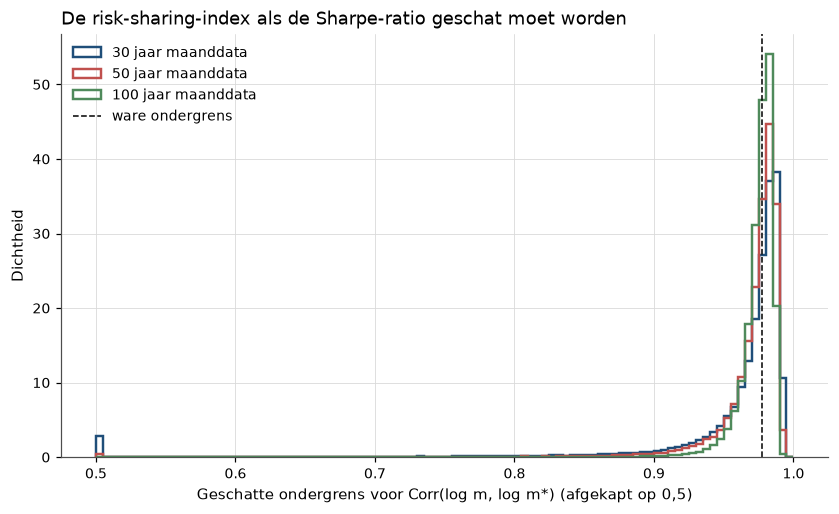

In [4]:
fig, ax = plt.subplots()
bins = np.linspace(0.5, 1.0, 101)
for k, (years, draws) in enumerate(bcs_draws.items()):
    ax.hist(np.clip(draws, 0.5, 1.0), bins=bins, histtype="step", lw=1.6, density=True,
            color=hap.plotting.COLORS[k], label=f"{years} jaar maanddata")
ax.axvline(rho_true, color="black", ls="--", lw=1, label="ware ondergrens")
ax.set_xlabel("Geschatte ondergrens voor Corr(log m, log m*) (afgekapt op 0,5)")
ax.set_ylabel("Dichtheid")
ax.set_title("De risk-sharing-index als de Sharpe-ratio geschat moet worden")
ax.legend(loc="upper left")
plt.show()

:::{figure} #cel-wisselkoersen-sim-bcs
:label: fig-wisselkoersen-sim-bcs
:width: 90%

De verdeling van de impliciete ondergrens voor de SDF-correlatie. De massa ligt dicht bij de ware
waarde, want de index is ongevoelig voor de SDF-volatiliteit zolang die groot is ten opzichte van de
wisselkoers. De linkerstaart komt van steekproeven waarin de Sharpe-ratio toevallig laag uitvalt.
:::

De mediaan van de geschatte index ligt op de ware waarde, en ook met dertig jaar data valt hij in 93%
van de steekproeven boven 0,9: de wisselkoersvolatiliteit is zo precies gemeten (90%-interval 9,4 tot
10,6%) dat hij geen rol speelt. De onzekerheid zit in de Sharpe-ratio — motief 1 — en de index is daar
een sterk niet-lineaire functie van. Een Sharpe-ratio van 0,2, met dertig jaar data het 5%-kwantiel,
geeft een index van 0,87; een Sharpe-ratio van 0,1 geeft 0,50, en onder 0,07 wordt de index negatief.
De puzzel verdwijnt pas als de ware Sharpe-ratio veel lager is dan we denken: dezelfde uitweg als bij
de equity premium puzzle.

### (b) De carry trade met sprongen: hoe vaak ziet dertig jaar er gratis uit?

We nemen een strategie *zonder* risicopremie. In normale maanden verdient ze $\mu = -\pi J$ met een
volatiliteit van 2,5% per maand (8,7% per jaar, ongeveer die van een G10-carry-portefeuille); met kans
$\pi = 1/360$ per maand crasht ze met $J = -30\%$, gemiddeld één keer per dertig jaar.

In [5]:
YEARS_PESO, SIGMA_PESO, JUMP, N_PESO = 30, 0.025, -0.30, 20_000
T_peso = 12 * YEARS_PESO


def peso_samples(pi, n=N_PESO):
    """Monthly returns with zero true mean: normal months earn -pi*J, crashes of size JUMP."""
    crash = rng.random((n, T_peso)) < pi
    returns = -pi * JUMP + SIGMA_PESO * rng.standard_normal((n, T_peso)) + JUMP * crash
    mean, sd = returns.mean(axis=1), returns.std(axis=1, ddof=1)
    skew = ((returns - mean[:, None]) ** 3).mean(axis=1) / returns.std(axis=1) ** 3
    return {"no_crash": ~crash.any(axis=1), "sharpe": np.sqrt(12) * mean / sd,
            "t": mean / (sd / np.sqrt(T_peso)), "skew": skew}


PI_BASE = 1 / 360
peso = peso_samples(PI_BASE)
nc = peso["no_crash"]
pd.Series({
    "P(geen crash), simulatie": nc.mean(),
    "P(geen crash), (1-pi)^T": (1 - PI_BASE) ** T_peso,
    "gem. SR zonder crash": peso["sharpe"][nc].mean(),
    "theorie: pi|J| sqrt(12) / sigma": PI_BASE * abs(JUMP) * np.sqrt(12) / SIGMA_PESO,
    "P(t > 2 | geen crash)": np.mean(peso["t"][nc] > 2),
    "P(t > 2), alle steekproeven": np.mean(peso["t"] > 2),
    "mediane scheefheid zonder crash": np.median(peso["skew"][nc]),
    "mediane scheefheid met crash": np.median(peso["skew"][~nc]),
}).round(3)

P(geen crash), simulatie           0.369
P(geen crash), (1-pi)^T            0.367
gem. SR zonder crash               0.115
theorie: pi|J| sqrt(12) / sigma    0.115
P(t > 2 | geen crash)              0.085
P(t > 2), alle steekproeven        0.035
mediane scheefheid zonder crash   -0.001
mediane scheefheid met crash      -3.331
dtype: float64

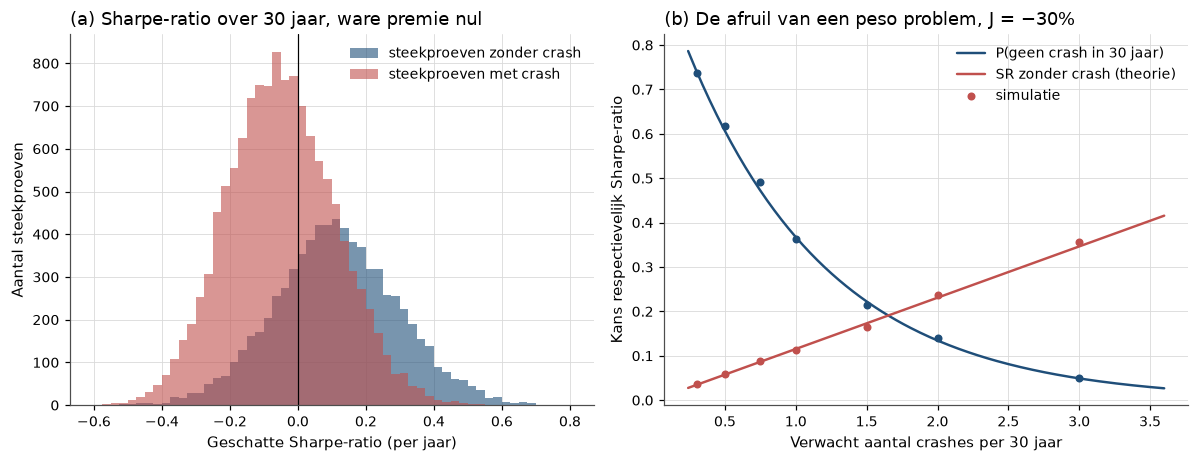

In [6]:
pis = np.array([1 / 1200, 1 / 720, 1 / 480, 1 / 360, 1 / 240, 1 / 180, 1 / 120])
sim_nc, sim_sr = [], []
for pi in pis:
    draw = peso_samples(pi, n=4_000)
    sim_nc.append(draw["no_crash"].mean())
    sim_sr.append(draw["sharpe"][draw["no_crash"]].mean() if draw["no_crash"].any() else np.nan)
pi_grid = np.linspace(1 / 1500, 1 / 100, 200)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
bins = np.linspace(-0.6, 0.8, 57)
axes[0].hist(peso["sharpe"][nc], bins=bins, alpha=0.6, label="steekproeven zonder crash")
axes[0].hist(peso["sharpe"][~nc], bins=bins, alpha=0.6, label="steekproeven met crash")
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("(a) Sharpe-ratio over 30 jaar, ware premie nul")
axes[0].set_xlabel("Geschatte Sharpe-ratio (per jaar)")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].legend()
axes[1].plot(360 * pi_grid, (1 - pi_grid) ** T_peso, color="C0", label="P(geen crash in 30 jaar)")
axes[1].plot(360 * pi_grid, pi_grid * abs(JUMP) * np.sqrt(12) / SIGMA_PESO, color="C1",
             label="SR zonder crash (theorie)")
axes[1].scatter(360 * pis, sim_nc, color="C0", s=18, zorder=3)
axes[1].scatter(360 * pis, sim_sr, color="C1", s=18, zorder=3, label="simulatie")
axes[1].set_title("(b) De afruil van een peso problem, J = −30%")
axes[1].set_xlabel("Verwacht aantal crashes per 30 jaar")
axes[1].set_ylabel("Kans respectievelijk Sharpe-ratio")
axes[1].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-wisselkoersen-sim-peso
:label: fig-wisselkoersen-sim-peso
:width: 100%

Links: een strategie zonder premie heeft in ruim een derde van de dertigjarige steekproeven geen crash,
en ziet er dan winstgevend en symmetrisch uit. Rechts: hoe vaker de crash, hoe hoger de schijnbare
Sharpe-ratio zonder crash, maar hoe kleiner de kans op zo'n steekproef.
:::

In 37% van de steekproeven valt geen crash: het gemiddelde is dan naar boven vertekend en de
scheefheid nul, dus de onderzoeker ziet het risico letterlijk niet. Maar de schijnbare Sharpe-ratio is
klein, $\pi|J|\sqrt{12}/\sigma = 0{,}115$, en maar 8,5% van die steekproeven haalt $t > 2$ (3,5% van
alle steekproeven). Om de Sharpe-ratio van 0,44 te maken die we hieronder in de data vinden, is
$\pi = 0{,}44 \cdot 0{,}025/(0{,}30\sqrt{12}) = 0{,}0106$ per maand nodig, één crash per acht jaar, en
dan is de kans op dertig jaar zonder crash $(1 - 0{,}0106)^{360} \approx 2\%$. Dat is het argument van
Burnside, Eichenbaum, Kleshchelski en Rebelo in één figuur: een peso problem zit in de *prijs* van de
slechte toestand — een zeer hoge SDF — en niet in een onwaarschijnlijk grote sprong in het rendement.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Eugene F. Fama, *Forward and Spot Exchange Rates*, Journal of Monetary Economics 1984
{cite}`Fama1984`; Hanno Lustig en Adrien Verdelhan, *The Cross Section of Foreign Currency Risk Premia
and Consumption Growth Risk*, American Economic Review 2007 {cite}`LustigVerdelhan2007`, met de
HML$_{FX}$-constructie van {cite:t}`LustigRoussanovVerdelhan2011`; Michael W. Brandt, John H. Cochrane
en Pedro Santa-Clara, *International Risk Sharing Is Better Than You Think, or Exchange Rates Are Too
Smooth*, Journal of Monetary Economics 2006 {cite}`BrandtCochraneSantaClara2006`.

**Wat.** (1) De UIP-regressie [](#eq-wisselkoersen-fama) per valuta en gepoold. (2) Portefeuilles
gesorteerd op renteverschil en HML$_{FX}$: gemiddelde, Sharpe-ratio, scheefheid, de crash van 2008 (LRV
2011, tabel 1: 483 basispunten, Sharpe-ratio 0,54 over 1983–2008). (3) De risk-sharing-index uit tabel 2
van BCS ("all at or above 0.98"). (4) Kort: momentum en value zoals in tabel I van
{cite:t}`AsnessMoskowitzPedersen2013`.

**Data hier.** FRED via `hap.data.fred`: dagelijkse spotkoersen (`DEXUSUK`, `DEXJPUS`, `DEXSZUS`,
`DEXCAUS`, `DEXUSAL`, `DEXUSNZ`, `DEXNOUS`, `DEXSDUS`, `DEXUSEU`) op maandeinde; OECD-driemaandsrentes
(`IR3TIB01xxM156N`, voor Japan tot 2002 de CD-rente `IR3TCD01JPM156N`, voor Zwitserland tot 1999 de
callgeldrente `IRSTCI01CHM156N`, voor de euro de Duitse reeks vanaf 1999); CPI's (`xxxCPIALLMINMEI`,
voor Australië en Nieuw-Zeeland kwartaalreeksen). Negen valuta's tegenover de dollar, 1976-01 tot
2025-12. Voor de Hansen-Jagannathan-grens de marktfactor en de 25 size/BM-portefeuilles van French via
`hap.data.french`.

**Verschil met het origineel.** Geen termijnkoersen: we nemen CIP aan, dus transactiekosten en
CIP-afwijkingen na 2008 ontbreken. De rentes zijn maandgemiddelden van driemaandsrentes, niet de
eenmaandsrente op de sorteerdatum. De Duitse mark ontbreekt vóór 1999 (FRED heeft alleen
maandgemiddelden). LV en LRV gebruiken veel meer valuta's, inclusief opkomende markten, en zes tot acht
portefeuilles; wij drie. BCS gebruiken reële rendementen en minimum-variantie-SDF's uit aandelen van
beide landen; wij nemen de Amerikaanse Sharpe-ratio voor beide SDF's.

**Verwachte afwijking.** (1) Hellingen onder één voor elke valuta, de meeste negatief, en een gepoolde
helling onder nul met $\beta = 1$ verworpen. (2) Een monotoon stijgend gemiddeld excess rendement van P1
naar P3, een HML$_{FX}$-Sharpe-ratio tussen 0,3 en 0,7 met negatieve scheefheid, en een verlies van ruwweg
tien procent of meer in het najaar van 2008. (3) Een risk-sharing-index boven 0,9 voor elke valuta. Een
HML$_{FX}$ met een negatief gemiddelde of een positieve scheefheid wijst op een fout in de code.
```

### De data

In [7]:
FX_CODES = {  # FRED id, True if quoted as USD per foreign unit
    "GBP": ("DEXUSUK", True), "JPY": ("DEXJPUS", False), "CHF": ("DEXSZUS", False),
    "CAD": ("DEXCAUS", False), "AUD": ("DEXUSAL", True), "NZD": ("DEXUSNZ", True),
    "NOK": ("DEXNOUS", False), "SEK": ("DEXSDUS", False), "EUR": ("DEXUSEU", True),
}
CURRENCIES = list(FX_CODES)
MONTHS = pd.date_range("1976-01-31", "2025-12-31", freq="ME")


def fred_month_end(code):
    """Last available observation of each month."""
    return hap_data.fred(code)[code].dropna().resample("ME").last()


def fred_rate(code):
    """Monthly OECD short rate as a decimal per year, stamped at month end."""
    return hap_data.fred(code)[code].dropna().resample("ME").mean() / 100


log_spot = pd.DataFrame(
    {c: (1 if usd_per_unit else -1) * np.log(fred_month_end(code)) for c, (code, usd_per_unit) in FX_CODES.items()}
).reindex(MONTHS)

rates = pd.DataFrame({
    "USD": fred_rate("IR3TIB01USM156N"),
    "GBP": fred_rate("IR3TIB01GBM156N"),
    "JPY": fred_rate("IR3TCD01JPM156N").loc[:"2002-03"].combine_first(fred_rate("IR3TIB01JPM156N")),
    "CHF": fred_rate("IRSTCI01CHM156N").loc[:"1999-06"].combine_first(fred_rate("IR3TIB01CHM156N")),
    "CAD": fred_rate("IR3TIB01CAM156N"),
    "AUD": fred_rate("IR3TIB01AUM156N"),
    "NZD": fred_rate("IR3TIB01NZM156N"),
    "NOK": fred_rate("IR3TIB01NOM156N"),
    "SEK": fred_rate("IR3TIB01SEM156N"),
    "EUR": fred_rate("IR3TIB01DEM156N").loc["1999":],
}).reindex(MONTHS)

rate_diff = rates[CURRENCIES].sub(rates["USD"], axis=0) / 12    # i*_t - i_t per month, known at t
ds_next = log_spot.diff().shift(-1)                               # Delta s_{t+1}, stored at t
rx_next = (rate_diff + ds_next).where(ds_next.notna())            # carry excess return t -> t+1, stored at t

pd.DataFrame({
    "eerste maand": rx_next.apply(lambda x: x.first_valid_index()).dt.strftime("%Y-%m"),
    "maanden": rx_next.notna().sum(),
    "gem. renteverschil (%/jr)": 1200 * rate_diff.mean(),
    "vol. wisselkoers (%/jr)": 100 * np.sqrt(12) * log_spot.diff().std(),
}).round(2)

,eerste maand,maanden,gem. renteverschil (%/jr),vol. wisselkoers (%/jr)
GBP,1976-01,598,1.36,9.95
JPY,1979-05,558,-2.44,10.98
CHF,1976-01,598,-2.93,11.26
CAD,1976-01,598,0.64,6.89
AUD,1976-01,598,2.28,11.05
NZD,1976-01,598,3.29,11.67
NOK,1979-01,562,1.64,10.73
SEK,1982-01,526,0.73,10.80
EUR,1999-01,322,-0.63,9.21


De wisselkoersvolatiliteiten liggen tussen ongeveer 7% (Canada) en 12% (Nieuw-Zeeland), dezelfde orde
van grootte als de 11,5 tot 12,9% van Brandt, Cochrane en Santa-Clara.

### (1) De Fama-regressie

We schatten [](#eq-wisselkoersen-fama) op maanddata met Newey-West-standaardfouten. De gepoolde
schatting gebruikt per valuta gedemeande variabelen en per maand geclusterde standaardfouten, omdat alle
valuta's tegen dezelfde dollar bewegen.

In [8]:
fama_rows = {}
for c in CURRENCIES:
    fit = hap.stats.newey_west(ds_next[c], -rate_diff[c], lags=3)
    b, se = fit.params.iloc[1], fit.bse.iloc[1]
    fama_rows[c] = {"helling": b, "SE": se, "t (helling = 0)": b / se, "t (helling = 1)": (b - 1) / se,
                    "R2 (%)": 100 * fit.rsquared, "maanden": int(fit.nobs)}

panel = pd.DataFrame({"ds": ds_next.stack(), "fwd": (-rate_diff).stack()}).dropna()
panel_dm = panel - panel.groupby(level=1).transform("mean")
pooled = sm.OLS(panel_dm["ds"], panel_dm[["fwd"]]).fit(
    cov_type="cluster", cov_kwds={"groups": panel_dm.index.get_level_values(0).factorize()[0]}
)
b, se = pooled.params.iloc[0], pooled.bse.iloc[0]
fama_rows["gepoold"] = {"helling": b, "SE": se, "t (helling = 0)": b / se, "t (helling = 1)": (b - 1) / se,
                        "R2 (%)": 100 * pooled.rsquared, "maanden": int(pooled.nobs)}
fama_table = pd.DataFrame(fama_rows).T
fama_table.round(2)

,helling,SE,t (helling = 0),t (helling = 1),R2 (%),maanden
GBP,-1.19,0.90,-1.32,-2.43,0.62,598.0
JPY,-1.34,0.69,-1.96,-3.41,0.69,558.0
CHF,-0.79,0.66,-1.19,-2.70,0.40,598.0
CAD,-0.22,0.54,-0.40,-2.24,0.02,598.0
AUD,-0.20,0.52,-0.39,-2.33,0.02,598.0
NZD,-0.82,0.50,-1.64,-3.64,0.53,598.0
NOK,-0.41,0.69,-0.60,-2.04,0.09,562.0
SEK,0.16,1.11,0.15,-0.75,0.01,526.0
EUR,-0.90,1.55,-0.58,-1.23,0.14,322.0
gepoold,-0.62,0.38,-1.61,-4.23,0.21,4958.0


Acht van de negen hellingen zijn negatief; alleen de Zweedse kroon heeft een kleine positieve helling
(0,16, standaardfout 1,1). Voor zeven valuta's verwerpt de $t$-toets $\beta = 1$ op het 5%-niveau, en de
gepoolde helling is $-0{,}62$ (standaardfout 0,38, $t = -4{,}2$ tegen $\beta = 1$). Maar tegen
$\beta = 0$ haalt geen enkele valuta $|t| > 2$ (de yen komt met $-1{,}96$ het dichtst bij). Dat is motief
1 in valutavorm: het renteverschil verklaart minder dan één procent van de maandelijkse variantie van
wisselkoersen, dus UIP verwerpen lukt met vijftig jaar data, het teken vastleggen nauwelijks. Via
[](#thm-wisselkoersen-decompositie) zegt de puntschatting toch iets scherps: de premie is volatieler dan
de verwachte depreciatie en er negatief mee gecorreleerd, en de helling van het carry-rendement op het
renteverschil is $1{,}62$.

### (2) Carry-portefeuilles

Elke maand sorteren we de beschikbare valuta's (minstens zes) op $i^*_t - i_t$ in drie gelijkgewogen
portefeuilles; HML$_{FX}$ is P3 min P1, en het rendement is [](#eq-wisselkoersen-rx).

In [9]:
def sort_portfolios(signal, returns_next, n_groups=3, min_assets=6):
    """Equal-weighted portfolios sorted on a signal at t; returns earned t -> t+1, indexed at t+1."""
    ranks = signal.where(returns_next.notna()).rank(axis=1, method="first")
    count = ranks.notna().sum(axis=1)
    group = np.ceil(ranks.mul(n_groups).div(count, axis=0))
    out = pd.DataFrame({f"P{g}": returns_next.where(group == g).mean(axis=1) for g in range(1, n_groups + 1)})
    out = out[count >= min_assets].copy()
    out["HML"] = out[f"P{n_groups}"] - out["P1"]
    out.index = out.index + pd.offsets.MonthEnd(1)
    return out


def portfolio_table(frame):
    """Annualised statistics with the standard error of the mean and of the Sharpe ratio."""
    stats = hap.stats.summary_stats(frame).astype({"nobs": int})
    years = stats["nobs"] / 12
    sharpe = stats["sharpe_ann"].astype(float)
    return pd.DataFrame({
        "gem. (%/jr)": 100 * stats["mean_ann"], "SE gem.": 100 * stats["se_mean_ann"],
        "vol. (%/jr)": 100 * stats["std_ann"], "Sharpe": sharpe,
        "SE Sharpe": np.sqrt((1 + sharpe**2 / 2) / years),
        "scheefheid": stats["skew"], "slechtste maand (%)": 100 * stats["min"],
        "maanden": stats["nobs"],
    }).astype(float)


carry = sort_portfolios(rate_diff, rx_next)
print(f"carry-portefeuilles {carry.index[0]:%Y-%m} t/m {carry.index[-1]:%Y-%m}")
portfolio_table(carry).round(2)

carry-portefeuilles 1979-02 t/m 2025-12


,gem. (%/jr),SE gem.,vol. (%/jr),Sharpe,SE Sharpe,scheefheid,slechtste maand (%),maanden
P1,-1.90,1.37,9.37,-0.20,0.15,0.31,-7.76,562.0
P2,-0.25,1.11,7.57,-0.03,0.15,-0.20,-10.37,562.0
P3,1.78,1.43,9.76,0.18,0.15,-0.55,-14.85,562.0
HML,3.67,1.22,8.37,0.44,0.15,-0.86,-11.21,562.0


In [10]:
carry_crisis = carry.loc["2008-08":"2008-12"]
hml_dd = hap.stats.drawdowns(np.expm1(carry.loc["2007-06":"2009-12", "HML"]))
worst = carry["HML"].nsmallest(5)
print(f"HML_FX aug-dec 2008: {100 * carry_crisis['HML'].sum():.1f}% (log, cumulatief)")
print(f"grootste drawdown 2007-06 t/m 2009-12: {100 * hml_dd.attrs['max_drawdown']:.1f}%, "
      f"dal in {hml_dd.attrs['trough']:%Y-%m}")
print(f"grootste drawdown volledige steekproef: {100 * hap.stats.drawdowns(np.expm1(carry['HML'])).attrs['max_drawdown']:.1f}%")
(100 * worst).round(1).rename("vijf slechtste maanden HML_FX (%)").to_frame().T

HML_FX aug-dec 2008: -26.6% (log, cumulatief)
grootste drawdown 2007-06 t/m 2009-12: -28.0%, dal in 2009-01
grootste drawdown volledige steekproef: -29.7%


,2008-10-31,1986-07-31,1987-10-31,1992-10-31,1995-03-31
vijf slechtste maanden HML_FX (%),-11.2,-11.2,-9.4,-8.4,-8.4


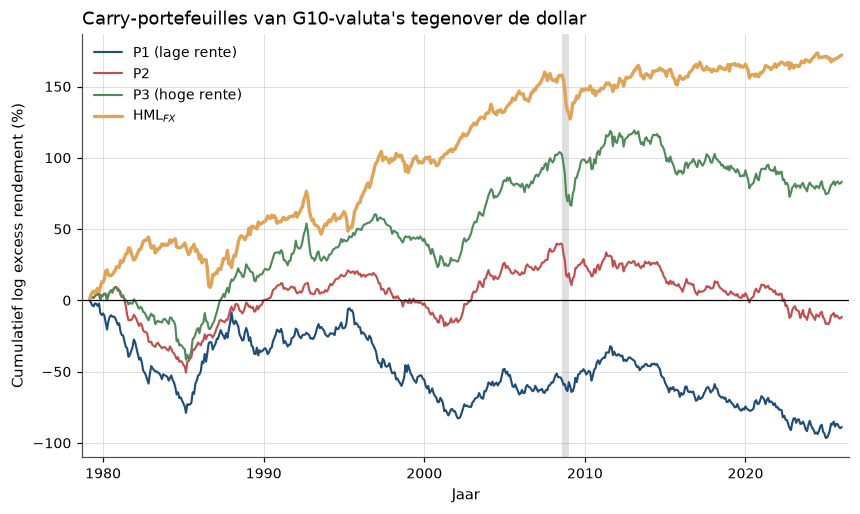

In [11]:
fig, ax = plt.subplots()
labels = {"P1": "P1 (lage rente)", "P2": "P2", "P3": "P3 (hoge rente)", "HML": "HML$_{FX}$"}
for k, col in enumerate(["P1", "P2", "P3", "HML"]):
    ax.plot(carry.index, 100 * carry[col].cumsum(), color=hap.plotting.COLORS[k], label=labels[col],
            lw=2.2 if col == "HML" else 1.4)
ax.axvspan(pd.Timestamp("2008-08-01"), pd.Timestamp("2008-12-31"), color="grey", alpha=0.25, lw=0)
ax.axhline(0, color="black", lw=0.8)
hap.plotting.timeline_axis(ax)
ax.set_xlabel("Jaar")
ax.set_ylabel("Cumulatief log excess rendement (%)")
ax.set_title("Carry-portefeuilles van G10-valuta's tegenover de dollar")
ax.legend()
plt.show()

:::{figure} #cel-wisselkoersen-carry
:label: fig-wisselkoersen-carry
:width: 90%

Cumulatieve log excess rendementen van drie portefeuilles gesorteerd op renteverschil. Lage-rentevaluta's
verliezen gestaag, hoge-rentevaluta's winnen gestaag, en een groot deel van het verschil gaat in het grijs
gemarkeerde najaar van 2008 in een paar maanden verloren: de trap en de lift.
:::

De portefeuilles beginnen in februari 1979, de eerste maand met zes valuta's. De rangorde is monotoon: P1
verliest 1,9% per jaar, P2 0,25% en P3 wint 1,8%. HML$_{FX}$ verdient 3,67% per jaar (standaardfout 1,22)
met een Sharpe-ratio van 0,44 (standaardfout 0,15), tussen de 0,39 die Lustig, Roussanov en Verdelhan voor
hun ontwikkelde landen en de 0,54 die ze voor hun volledige steekproef rapporteren — bij hen na kosten. De
scheefheid is $-0{,}86$ en komt van de hoge-rentekant (P3 $-0{,}55$, P1 $+0{,}31$). Van augustus tot en met
december 2008 verloor HML$_{FX}$ 26,6% (in logs), de drawdown tot januari 2009 was 28%, en oktober 2008 was
met $-11{,}2\%$ de slechtste maand, gelijk met juli 1986; ook oktober 1987 staat in de lijst. Een handvol
maanden bepaalt het risicoprofiel van 47 jaar.

### (3) Brandt, Cochrane en Santa-Clara op G10-data

We nemen de Sharpe-ratio van de Amerikaanse markt over dezelfde periode als grens voor beide SDF's,
zetten hem met [](#eq-wisselkoersen-logbound) om en berekenen [](#eq-wisselkoersen-rhomin) per valuta; ook
met de Sharpe-ratio min twee standaardfouten, en met de (in de steekproef overschatte) maximale
Sharpe-ratio van de 25 size/BM-portefeuilles plus de markt.

In [12]:
ff3 = hap_data.french("F-F_Research_Data_Factors").loc["1976":"2025"]
ff25 = hap_data.french("25_Portfolios_5x5").loc["1976":"2025"]
excess_25 = ff25.sub(ff3["RF"], axis=0).join(ff3["Mkt-RF"])
mu_vec = excess_25.mean().to_numpy()
max_sharpe = np.sqrt(12 * mu_vec @ np.linalg.solve(excess_25.cov().to_numpy(), mu_vec))

years_eq = len(ff3) / 12
sr_market = float(hap.stats.sharpe(ff3["Mkt-RF"]))
se_sr = np.sqrt((1 + sr_market**2 / 2) / years_eq)
bounds = {"markt": sr_market, "markt - 2 SE": sr_market - 2 * se_sr, "max. 25 + markt": max_sharpe}
print(f"Sharpe-ratio markt 1976-2025: {sr_market:.2f} (SE {se_sr:.2f}); "
      f"maximale Sharpe-ratio 25 portefeuilles + markt: {max_sharpe:.2f}")

fx_vol = np.sqrt(12) * log_spot.diff().loc["1976":"2025"].std()
bcs_table = pd.DataFrame({"vol. wisselkoers": fx_vol})
for name, sr in bounds.items():
    bcs_table[f"index ({name})"] = implied_corr(sr, fx_vol)
bcs_table.loc["gem. G10"] = bcs_table.mean()
bcs_table.round(3)

Sharpe-ratio markt 1976-2025: 0.56 (SE 0.15); maximale Sharpe-ratio 25 portefeuilles + markt: 1.56


,vol. wisselkoers,index (markt),index (markt - 2 SE),index (max. 25 + markt)
GBP,0.099,0.982,0.921,0.996
JPY,0.110,0.978,0.904,0.995
CHF,0.113,0.977,0.899,0.995
CAD,0.069,0.991,0.962,0.998
AUD,0.110,0.978,0.903,0.995
NZD,0.117,0.975,0.891,0.994
NOK,0.107,0.979,0.908,0.995
SEK,0.108,0.979,0.907,0.995
EUR,0.092,0.984,0.932,0.997
gem. G10,0.103,0.980,0.914,0.996


Met de Sharpe-ratio van de markt, 0,56 over 1976–2025, is de index gemiddeld 0,98, per valuta tussen 0,975
(Nieuw-Zeelandse dollar) en 0,991 (Canadese dollar): het getal uit tabel 2 van Brandt, Cochrane en
Santa-Clara, met andere landen, een andere periode en een ruwere methode. Met een Sharpe-ratio twee
standaardfouten lager (0,26) zakt hij naar gemiddeld 0,91, geen valuta onder 0,89; met de maximale
Sharpe-ratio van 1,56 stijgt hij naar 0,996. Dezelfde grens voor beide landen is verdedigbaar: BCS vonden
lokale Sharpe-ratio's van 0,26 (Japan) tot 0,63 (VS), maar minimum-variantie-SDF's van vergelijkbare
volatiliteit, "because all investors essentially have the same set of assets available to them". De
verwachting uit het replicatieblok komt uit, en is robuust omdat de verhouding van wisselkoersvariantie tot
SDF-variantie klein is, zoals simulatie (a) voorspelde.

### (4) Momentum en value in valuta

Momentum is het cumulatieve carry-excess rendement over maand $t-11$ tot en met $t-1$ (de 12-1-regel van
[](#04-19-momentum)). Value is, zoals bij {cite:t}`AsnessMoskowitzPedersen2013`, minus de verandering van
de log reële wisselkoers $q = s + p^* - p$ over vijf jaar, met CPI's die drie maanden achterlopen.

In [13]:
CPI_CODES = {"USD": "USACPIALLMINMEI", "GBP": "GBRCPIALLMINMEI", "JPY": "JPNCPIALLMINMEI",
             "CHF": "CHECPIALLMINMEI", "CAD": "CANCPIALLMINMEI", "AUD": "AUSCPIALLQINMEI",
             "NZD": "NZLCPIALLQINMEI", "NOK": "NORCPIALLMINMEI", "SEK": "SWECPIALLMINMEI",
             "EUR": "DEUCPIALLMINMEI"}


def log_cpi(code):
    """Log CPI at month end; quarterly series are carried forward within the quarter."""
    series = hap_data.fred(code)[code]
    series = series[series > 0].resample("ME").last()
    return np.log(series).ffill(limit=2)


cpi = pd.DataFrame({c: log_cpi(code) for c, code in CPI_CODES.items()}).reindex(MONTHS)
real_fx = log_spot + cpi[CURRENCIES].sub(cpi["USD"], axis=0)

momentum_signal = rx_next.shift(2).rolling(11, min_periods=11).sum()
value_signal = -(real_fx.shift(3) - real_fx.shift(63))

momentum = sort_portfolios(momentum_signal, rx_next)
value = sort_portfolios(value_signal, rx_next)
factors = pd.DataFrame({"carry": carry["HML"], "momentum": momentum["HML"], "value": value["HML"]}).dropna()
factors["50/50 momentum-value"] = 0.5 * (factors["momentum"] + factors["value"])
factors["gelijk gewogen, drie"] = factors[["carry", "momentum", "value"]].mean(axis=1)
print(f"gemeenschappelijke steekproef {factors.index[0]:%Y-%m} t/m {factors.index[-1]:%Y-%m}")
print("correlaties:")
print(factors[["carry", "momentum", "value"]].corr().round(2).to_string())
portfolio_table(factors).round(2)

gemeenschappelijke steekproef 1981-05 t/m 2025-07
correlaties:
          carry  momentum  value
carry      1.00      0.17   0.10
momentum   0.17      1.00  -0.29
value      0.10     -0.29   1.00


,gem. (%/jr),SE gem.,vol. (%/jr),Sharpe,SE Sharpe,scheefheid,slechtste maand (%),maanden
carry,3.10,1.29,8.50,0.36,0.16,-0.87,-11.21,519.0
momentum,0.64,1.32,8.65,0.07,0.15,-0.40,-9.37,519.0
value,3.92,1.26,8.28,0.47,0.16,0.13,-10.27,519.0
50/50 momentum-value,2.28,0.77,5.04,0.45,0.16,0.40,-7.64,519.0
"gelijk gewogen, drie",2.55,0.74,4.86,0.52,0.16,-0.71,-8.22,519.0


Over 1981–2025 heeft value een Sharpe-ratio van 0,47, dicht bij de 0,44 van Asness, Moskowitz en Pedersen,
en carry 0,36. Momentum doet met 0,07 vrijwel niets (zij vonden 0,32), maar met een standaardfout van 0,15
is dat verschil ongeveer anderhalve standaardfout. Momentum en value zijn negatief gecorreleerd ($-0{,}29$),
carry met beide nauwelijks. Een gelijkgewogen mix van de drie haalt daardoor 0,52 bij een volatiliteit van
4,9% per jaar; de crash van carry verdwijnt niet (scheefheid $-0{,}71$) maar wordt verdund. Dat is de kern
van Barroso en Santa-Clara: een portefeuille van kenmerken die elk een ander risico dragen.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** De identiteit [](#eq-wisselkoersen-identiteit) koppelt het SDF-raamwerk
rechtstreeks aan data. Ze verklaart waarom rentes, wisselkoersen en risicopremies samenhangen, waarom de munt
van een land met volatiel marginaal nut een lage rente heeft en in crises appreciëert, en waarom een
UIP-helling onder nul een risicopremie kan zijn in plaats van irrationaliteit. Brandt, Cochrane en Santa-Clara
haalden er een uitspraak over internationale risk sharing uit die op onze G10-data letterlijk terugkomt: 0,98.

**Waar het breekt.** Op dezelfde data. De gepoolde Fama-helling is $-0{,}62$ in plaats van één, en
HML$_{FX}$ verdient een Sharpe-ratio van 0,44 met een scheefheid van $-0{,}86$ en een verlies van 28% in
2008; daarna zakte de Sharpe-ratio naar 0,13 (oefening [](#ex-wisselkoersen-2)). Het lognormale model maakt
dat teken alleen als de rente daalt met de SDF-variantie, en dan volgens Backus, Foresi en Telmer ten koste
van negatieve rentes of asymmetrische landen; een SDF-correlatie van 0,98 staat bovendien haaks op
consumptiedata. De theorie heeft het feit niet voorspeld maar er achteraf ruimte voor gemaakt: motief 3, een
theorie-met-tests die een feit-met-concurrerende-theorieën werd.

**Risico of vergissing?** De Chicago-lezing: carry is een beloning voor wereldwijd risico. Hoge-rentevaluta's
verliezen als de wereldwijde volatiliteit onverwacht stijgt {cite}`MenkhoffSarnoSchmelingSchrimpf2012a`, laden
op één gemeenschappelijke factor {cite}`LustigRoussanovVerdelhan2011`, en hun peso problem is een toestand
waarin een dollar extreem veel waard is {cite}`BurnsideEichenbaumKleshchelskiRebelo2011`; dat de grootste
verliezen in oktober 1987 en najaar 2008 vallen, past daarbij. De Yale-lezing: de winst is een vergissing die
blijft bestaan omdat arbitrage beperkt is. Menkhoff en coauteurs zien in valutamomentum "behavior consistent
with investor under- and overreaction" en "very effective limits to arbitrage"
{cite}`MenkhoffSarnoSchmelingSchrimpf2012b`, Brunnermeier, Nagel en Pedersen verklaren crashes uit gedwongen
afbouw als financieringsliquiditeit opdroogt {cite}`BrunnermeierNagelPedersen2008`, en Barroso en Santa-Clara
concluderen dat valutarendementen "besides risk" ook "the scarcity of speculative capital" weerspiegelen
{cite}`BarrosoSantaClara2015b`. Wat de kampen zou scheiden, is de waarde van de SDF in zeldzame
crisistoestanden, en die is met vijftig jaar vlottende wisselkoersen en een handvol crises niet te meten.

**Wat er daarna kwam.** Barroso en Santa-Clara vervingen het sorteren op één kenmerk door gewichten die
rechtstreeks als functie van kenmerken worden geschat; die parametrische portefeuilles zijn het onderwerp van
[](#05-31-portfolio-choice).

## Oefeningen

:::{exercise}
:label: ex-wisselkoersen-1

**De ondergrens voor de SDF-correlatie.** Laat $\SD(\log m) = \sigma \geq a$, $\SD(\log m^*) = \sigma^*
\geq a$ en $\Var(\Delta s) = V$.

1. Laat met [](#eq-wisselkoersen-bcs) zien dat
   $\Corr(\log m, \log m^*) = 1 + \big((\sigma - \sigma^*)^2 - V\big)/(2\sigma\sigma^*)$, en leid
   [](#eq-wisselkoersen-rhomin) af. Wanneer geldt gelijkheid?
2. Reken het voorbeeld van Brandt, Cochrane en Santa-Clara na ($\SD(\Delta s) = 0{,}10$, $a = 0{,}5$) en
   bereken hoe volatiel wisselkoersen bij ongecorreleerde SDF's zouden zijn.
3. Welke Sharpe-ratio geeft volgens [](#eq-wisselkoersen-logbound) bij de G10-wisselkoersvolatiliteit van
   hierboven een index van 0,5?
:::

:::{solution} ex-wisselkoersen-1
:class: dropdown

**(1)** Uit [](#eq-wisselkoersen-bcs) is $\Corr = (\sigma^2 + \sigma^{*2} - V)/(2\sigma\sigma^*)$; schrijf
$\sigma^2 + \sigma^{*2} = (\sigma - \sigma^*)^2 + 2\sigma\sigma^*$. De eerste term is niet-negatief, dus
$\Corr \geq 1 - V/(2\sigma\sigma^*) \geq 1 - V/(2a^2)$, omdat $\sigma\sigma^* \geq a^2$. Gelijkheid geldt
precies bij $\sigma = \sigma^* = a$.

**(2) en (3)**

In [14]:
V_bcs, a_bcs = 0.10**2, 0.5
print(f"index BCS-voorbeeld: {1 - V_bcs / (2 * a_bcs**2):.2f}")
print(f"wisselkoersvolatiliteit bij correlatie nul: {np.sqrt(2) * a_bcs:.3f}")
vol_g10 = float(bcs_table.loc["gem. G10", "vol. wisselkoers"])
a2_needed = vol_g10**2 / (2 * (1 - 0.5))
print(f"G10-vol {vol_g10:.3f}: index 0.5 vraagt log-SDF-vol {np.sqrt(a2_needed):.3f}, "
      f"dus een Sharpe-ratio van {np.sqrt(np.expm1(a2_needed)):.3f}")

index BCS-voorbeeld: 0.98
wisselkoersvolatiliteit bij correlatie nul: 0.707
G10-vol 0.103: index 0.5 vraagt log-SDF-vol 0.103, dus een Sharpe-ratio van 0.103


Ongecorreleerde SDF's vereisen wisselkoersen van 71% per jaar, en een index van 0,5 een Sharpe-ratio rond 0,1.
Wat de oefening leert: de conclusie van Brandt, Cochrane en Santa-Clara volgt uit de orde van grootte van twee
getallen, niet uit randgevallen van hun aannames.
:::

:::{exercise}
:label: ex-wisselkoersen-2

**Voor en na 2008.** Gebruik `panel`, `carry` en `portfolio_table` uit de replicatie. Schat de gepoolde
Fama-helling apart voor formatiedata 1979–2007 en 2008–2025, bereken voor dezelfde periodes de statistieken
van HML$_{FX}$, en beoordeel wat een onderzoeker eind 2007 had geconcludeerd.
:::

:::{solution} ex-wisselkoersen-2
:class: dropdown

In [15]:
def pooled_fama(frame):
    """Pooled UIP slope with currency fixed effects and month-clustered standard errors."""
    dm = frame - frame.groupby(level=1).transform("mean")
    fit = sm.OLS(dm["ds"], dm[["fwd"]]).fit(
        cov_type="cluster", cov_kwds={"groups": dm.index.get_level_values(0).factorize()[0]}
    )
    return fit.params.iloc[0], fit.bse.iloc[0]


dates = panel.index.get_level_values(0)
split_rows = {}
for label, (start, end) in {"1979-2007": ("1979-01-01", "2007-12-31"),
                            "2008-2025": ("2008-01-01", "2025-12-31")}.items():
    b_sub, se_sub = pooled_fama(panel[(dates >= start) & (dates <= end)])
    hml_stats = portfolio_table(carry.loc[start:end, ["HML"]]).iloc[0]
    split_rows[label] = {"Fama-helling": b_sub, "SE": se_sub, "t (helling = 1)": (b_sub - 1) / se_sub,
                         **hml_stats[["gem. (%/jr)", "SE gem.", "Sharpe", "SE Sharpe", "scheefheid",
                                      "slechtste maand (%)"]].to_dict()}
pd.DataFrame(split_rows).T.round(2)

,Fama-helling,SE,t (helling = 1),gem. (%/jr),SE gem.,Sharpe,SE Sharpe,scheefheid,slechtste maand (%)
1979-2007,-1.01,0.45,-4.44,5.34,1.65,0.60,0.20,-0.95,-11.21
2008-2025,1.39,1.38,0.28,0.99,1.75,0.13,0.24,-0.76,-11.21


Eind 2007 zag carry eruit als een gevestigde regelmaat: een gepoolde helling van $-1{,}01$, bijna het
"dubbele renteverschil" uit [](#thm-wisselkoersen-decompositie), en een Sharpe-ratio van 0,60 (standaardfout
0,20). Na 2008 is de helling positief (1,39, standaardfout 1,38; de G10-renteverschillen waren jarenlang bijna
nul) en de Sharpe-ratio 0,13 (standaardfout 0,24). Wat de oefening leert: een premie die met dertig jaar data
zeker leek, is na één crash niet meer aantoonbaar — passend bij een uitbetaalde risicopremie én bij een
weggearbitreerde anomalie; het 2%-motief laat de data niet kiezen.
:::

:::{exercise}
:label: ex-wisselkoersen-3

**Een parametrische valutaportefeuille.** Standaardiseer elke maand carry, momentum en value over de
valuta's waarvoor alle drie beschikbaar zijn, en neem $w_{i,t} = \boldsymbol{\theta}'\mathbf{z}_{i,t}/N_t$.

1. Laat zien dat het portefeuillerendement $\boldsymbol{\theta}'\mathbf{F}_{t+1}$ is, met
   $F_{k,t+1} = \frac{1}{N_t}\sum_i z_{k,i,t}\, rx_{i,t+1}$, en dat de $\boldsymbol{\theta}$ die
   $\E[r_p] - \tfrac{\gamma}{2}\Var(r_p)$ maximaliseert, evenredig is met
   $\boldsymbol{\Sigma}_F^{-1}\boldsymbol{\mu}_F$.
2. Schat $\boldsymbol{\theta}$ op 1981–2002 en evalueer op 2003–2025, tegenover alleen carry en gelijke
   gewichten.
:::

:::{solution} ex-wisselkoersen-3
:class: dropdown

**(1)** $r_{p,t+1} = \sum_i w_{i,t}\, rx_{i,t+1} = \boldsymbol{\theta}'\mathbf{F}_{t+1}$, dus
$\E[r_p] - \tfrac{\gamma}{2}\Var(r_p) = \boldsymbol{\theta}'\boldsymbol{\mu}_F -
\tfrac{\gamma}{2}\boldsymbol{\theta}'\boldsymbol{\Sigma}_F\boldsymbol{\theta}$, met eerste-ordevoorwaarde
$\boldsymbol{\theta} = \gamma^{-1}\boldsymbol{\Sigma}_F^{-1}\boldsymbol{\mu}_F$: een mean-variance-probleem met
drie "kenmerkportefeuilles".

**(2)**

In [16]:
signals = {"carry": rate_diff, "momentum": momentum_signal, "value": value_signal}
available = rx_next.notna()
for sig in signals.values():
    available &= sig.notna()
n_avail = available.sum(axis=1)


def cross_section_z(signal):
    """Cross-sectional z-score over currencies with all signals and a next-month return."""
    x = signal.where(available)
    return x.sub(x.mean(axis=1), axis=0).div(x.std(axis=1), axis=0)


char_returns = pd.DataFrame(
    {k: (cross_section_z(sig) * rx_next).sum(axis=1, min_count=1) / n_avail for k, sig in signals.items()}
)[n_avail >= 6].dropna()
char_returns.index = char_returns.index + pd.offsets.MonthEnd(1)

train, test = char_returns.loc["1981":"2002"], char_returns.loc["2003":"2025"]
theta = np.linalg.solve(train.cov().to_numpy(), train.mean().to_numpy())
policies = {"optimaal (in-sample geschat)": theta, "alleen carry": np.array([1.0, 0.0, 0.0]),
            "gelijke gewichten": np.ones(3)}
rows_pp = {}
for name, th in policies.items():
    scale = 0.10 / (np.sqrt(12) * (train @ th).std())                 # 10% volatility in the training sample
    for label, sample in {"1981-2002": train, "2003-2025": test}.items():
        r_p = scale * (sample @ th)
        rows_pp[(name, label)] = {"Sharpe": float(hap.stats.sharpe(r_p)), "vol. (%/jr)": 100 * np.sqrt(12) * r_p.std(),
                                  "scheefheid": r_p.skew()}
print("theta (genormeerd):", dict(zip(char_returns.columns, (theta / np.abs(theta).sum()).round(2))))
pd.DataFrame(rows_pp).T.round(2)

theta (genormeerd): {'carry': np.float64(0.15), 'momentum': np.float64(0.21), 'value': np.float64(0.64)}


Sharpe  vol. (%/jr)  scheefheid
optimaal (in-sample geschat) 1981-2002    1.02        10.00       -0.77
                             2003-2025    0.24         7.01        1.85
alleen carry                 1981-2002    0.56        10.00       -0.93
                             2003-2025    0.18         8.29       -0.87
gelijke gewichten            1981-2002    0.87        10.00       -0.78
                             2003-2025    0.26         5.84       -0.09

In de schattingsperiode legt de optimale portefeuille het meeste gewicht op value, met een Sharpe-ratio van
1,02; buiten de steekproef is dat 0,24, iets onder gelijke gewichten (0,26) en boven carry alleen (0,18). Dat is
het Michaud-effect uit [](#01-04-markowitz): $\boldsymbol{\Sigma}_F^{-1}\boldsymbol{\mu}_F$ versterkt de
schattingsfout in $\boldsymbol{\mu}_F$. Wat de oefening leert: de winst zit vooral in het combineren van
kenmerken met verschillend risico; geschatte gewichten helpen pas als de schattingsfout wordt ingetoomd, het
onderwerp van [](#05-31-portfolio-choice).
:::